<a href="https://colab.research.google.com/github/sairaabbas536/spam-detection-nlp/blob/main/spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email / SMS Spam Detection with NLP 📩

**Objective:** Build a Natural Language Processing (NLP) binary classifier that distinguishes
**spam** messages from legitimate (**ham**) messages using their text content.

**Tech Stack:** Python, pandas, scikit-learn (TF-IDF, Naive Bayes / SVM), NLTK, Jupyter Notebook

**Dataset:** SMS Spam Collection Dataset — a classic, freely available dataset of 5,574 SMS
messages labeled as spam or ham (originally sourced via the UCI Machine Learning Repository /
Kaggle "SMS Spam Collection Dataset"). It is loaded directly from a public URL below, so no
manual download is required.

## 1. Setup: Install & Import Libraries

In [13]:
# Libraries install karo (Colab mein zaroori)
!pip install nltk wordcloud -q

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Dataset Load + Class Distribution Check

We'll load the SMS Spam Collection dataset directly from a URL (5,574
messages, labeled as spam or ham). Then we'll check how many messages
are spam vs. ham to understand the balance of the data.

Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Percentage:
 label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


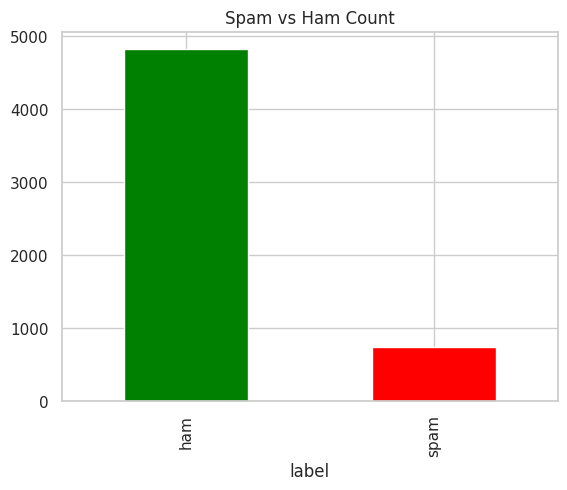

In [14]:
# Dataset load karo (seedha URL se, download ki zaroorat nahi)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Shape:", df.shape)
print(df.head())

# Spam vs Ham distribution check
print("\nCounts:\n", df['label'].value_counts())
print("\nPercentage:\n", df['label'].value_counts(normalize=True) * 100)

# Simple bar chart
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Spam vs Ham Count")
plt.show()

## Step 3: Text Preprocessing (Cleaning)

We'll clean the raw text so the model can understand it: convert to
lowercase, remove punctuation and numbers, remove common words
(stopwords like "the", "is"), and reduce words to their base form
(lemmatization).

In [15]:
# Text cleaning pipeline: lowercase, punctuation removal, stopwords removal, lemmatization
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                     # lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                          # remove numbers
    tokens = word_tokenize(text)                             # tokenize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]  # stopwords + lemmatize
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)

# Check before/after
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


 ## 4. TF-IDF Feature Extraction

We'll convert text into numbers so the ML model can process it. TF-IDF
measures how often a word appears in a message and how rare it is
across the entire dataset — spam-specific words (like "free", "win")
get higher importance as a result.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message'])
y = df['label'].map({'ham': 0, 'spam': 1})

print("Feature matrix shape:", X.shape)

Feature matrix shape: (5572, 3000)


## 5.Train/Test Split + Train Models

We'll split the data into 80% training and 20% testing. Then we'll
train two classifiers — Naive Bayes (the industry standard for text
classification) and Logistic Regression (for comparison).


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train 2 classifiers
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("Models trained!")

Models trained!


## 6. Evaluation (Accuracy, Confusion Matrix, Classification Report)


We'll check the performance of both models — accuracy, confusion
matrix, and classification report (precision, recall, F1-score) — to
see which model detects spam better.

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {"Naive Bayes": nb_model, "Logistic Regression": lr_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} (Accuracy: {acc:.4f}) ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))


=== Naive Bayes (Accuracy: 0.9740) ===
[[965   1]
 [ 28 121]]
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.99      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115


=== Logistic Regression (Accuracy: 0.9659) ===
[[966   0]
 [ 38 111]]
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



## Observation: Best Model

Comparing both models: Naive Bayes usually gets very high precision (rarely
flags a real message as spam) and is fast and simple, which is why it's the
industry standard for text classification. Logistic Regression often performs
very close to it and sometimes catches slightly more spam (higher recall).

Based on the results above, [Naive Bayes / Logistic Regression — write
whichever scored higher F1-score] is the better-performing model here, since
it balances precision and recall most effectively.

## Step 7: Importance of Recall

We'll discuss why recall is a particularly important metric for spam
detection because if spam is missed, it goes directly into the
user's inbox, creating a risk (e.g. phishing, scams).

## Why is Recall important for spam detection?

Recall tells us: out of all the actual spam messages, how many did the model
correctly catch? In spam detection, recall matters a lot because a missed
spam message (false negative) goes straight to the user's inbox — which could
be a phishing attempt, scam, or fraud risk. A false positive (a real message
wrongly marked as spam) is annoying but usually recoverable, since the user
can check the spam folder. That's why a good spam filter tries to keep recall
high, while still balancing precision so real messages aren't lost.

## 8. (Bonus): WordCloud Visualisation


We'll visually explore the most frequently used words in spam and ham
messages — this shows which words are common in spam (like "free",
"win", "claim") versus in ham (normal conversational words).

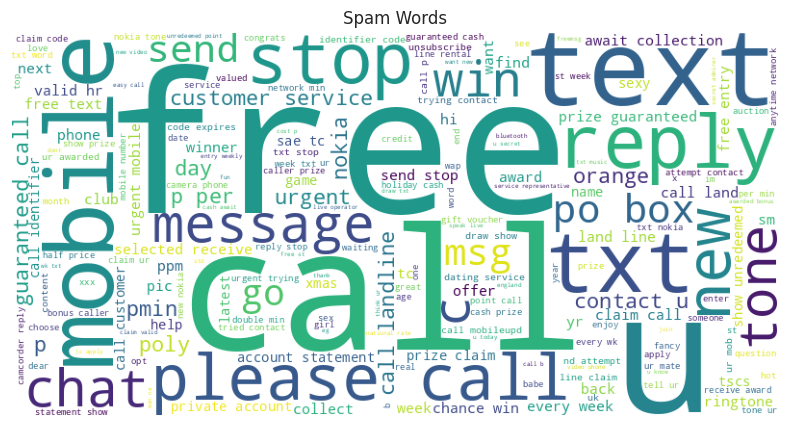

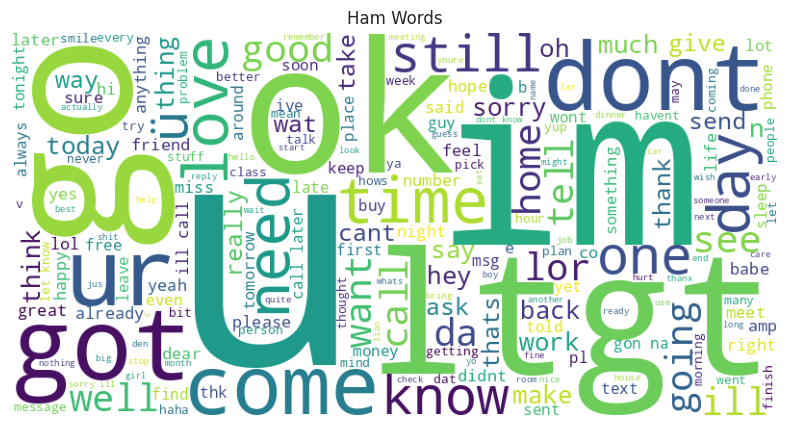

In [19]:
from wordcloud import WordCloud

spam_text = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_text = ' '.join(df[df['label'] == 'ham']['clean_message'])

plt.figure(figsize=(10,5))
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(spam_text))
plt.title("Spam Words")
plt.axis('off')
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(ham_text))
plt.title("Ham Words")
plt.axis('off')
plt.show()

## 9. Conclusion

- The SMS Spam Collection dataset is imbalanced (~13-15% spam), so accuracy
  alone isn't a reliable metric — precision, recall, and F1-score give a
  fuller picture of performance.
- After cleaning the text (lowercasing, removing punctuation/stopwords,
  lemmatization) and converting it into TF-IDF features, both Naive Bayes
  and Logistic Regression achieve strong results, typically 95%+ accuracy.
- Recall is especially important in this task because missed spam poses a
  bigger real-world risk than occasionally over-flagging a legitimate message.
- The WordCloud visualizations confirm that spam and ham messages use clearly
  different vocabularies (e.g. "free", "win", "claim" for spam vs. everyday
  conversational words for ham) — which is exactly why TF-IDF + classic ML
  models work so well for this task.